Imports

In [12]:
!pip install networkx
!pip install pennylane
!pip install pandas


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 9.0 MB/s  0:00:01 eta 0:00:01m

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [7]:
# Enable automatic reloading of imported modules
%load_ext autoreload
%autoreload 2

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp

# Import the core logic from your unified engine
from l_vqe_engine import (
    build_k_community_hamiltonian,
    best_known_community_cost,
    simulate_one_lvqe,
    total_qubits
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


=== 1. GRAPH SETUP & BASELINE ===


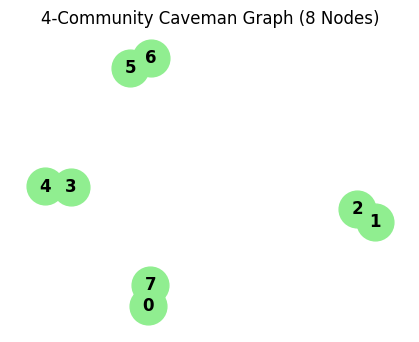

Calculating exact classical baseline...
True Maximum Modularity (C_bkv): 0.750000
Total Qubits Required: 16


In [8]:
print("=== 1. GRAPH SETUP & BASELINE ===")

# Generate the 8-node (4 communities of 2 nodes) Caveman Graph
G_test = nx.connected_caveman_graph(l=4, k=2)
k_target = 4
n_nodes = G_test.number_of_nodes()
n_qubits = total_qubits(n_nodes, k_target)

# Visualize the graph
plt.figure(figsize=(4, 3))
nx.draw(G_test,  with_labels=True, 
    node_color='lightgreen', 
    edge_color='dimgray',
    width=2.0,
    font_weight='bold',
    node_size=700)
plt.title(f"4-Community Caveman Graph ({n_nodes} Nodes)")
plt.show()

# Calculate absolute true baseline using the exact modularity math
print("Calculating exact classical baseline...")
true_baseline = best_known_community_cost(G_test, k=k_target)
print(f"True Maximum Modularity (C_bkv): {true_baseline:.6f}")
print(f"Total Qubits Required: {n_qubits}")

In [9]:
print("\n=== 2. L-VQE (COBYLA) EXECUTION ===")

# Build the exact qubit-frugal Hamiltonian
H_comm = build_k_community_hamiltonian(G_test, k_target)

# Run L-VQE with COBYLA
rng_cobyla = np.random.default_rng(42)
cobyla_results = simulate_one_lvqe(
    n_q=n_qubits,
    H=H_comm,
    max_layers=2,
    shots=None,               # Statevector simulation
    max_iter_per_layer=600,   # Gives the 3,000 total budget
    rng=rng_cobyla,
    optimizer="COBYLA",
    device_name="lightning.qubit"
)

# Remember: VQE minimizes cost (negative modularity), so we flip the sign
cobyla_modularity = -cobyla_results['final_cost']
cobyla_rho = cobyla_modularity / true_baseline

print(f"\nCOBYLA Final Modularity: {cobyla_modularity:.6f}")
print(f"COBYLA Approximation Ratio (ρ): {cobyla_rho:.4f}")


=== 2. L-VQE (COBYLA) EXECUTION ===
  Layer 0  (16 params) ... cost = -0.750000
  Layer 1  (76 params) ... cost = -0.750000
  Layer 2  (136 params) ... cost = -0.750000

COBYLA Final Modularity: 0.750000
COBYLA Approximation Ratio (ρ): 1.0000


In [41]:
print("\n=== 3. L-VQE (SMO) EXECUTION ===")

# We use the exact same random seed so both optimizers start on the exact same point on the mountain
rng_smo = np.random.default_rng(42) 

smo_results = simulate_one_lvqe(
    n_q=n_qubits,
    H=H_comm,
    max_layers=2,
    shots=None,
    max_iter_per_layer=600,
    rng=rng_smo,
    optimizer="SMO",
    device_name="lightning.qubit"
)

smo_modularity = -smo_results['final_cost']
smo_rho = smo_modularity / true_baseline

print(f"\nSMO Final Modularity: {smo_modularity:.6f}")
print(f"SMO Approximation Ratio (ρ): {smo_rho:.4f}")


=== 3. L-VQE (SMO) EXECUTION ===
  Layer 0  (16 params) ... cost = -0.625000
  Layer 1  (76 params) ... cost = -0.750000
  Layer 2  (136 params) ... cost = -0.750000

SMO Final Modularity: 0.750000
SMO Approximation Ratio (ρ): 1.0000



=== 4. OPTIMIZER TRAJECTORY COMPARISON ===


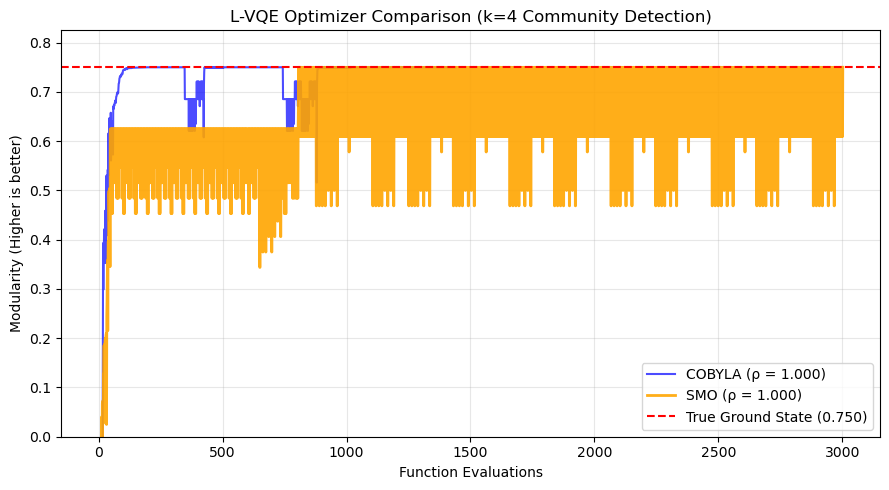

In [42]:
print("\n=== 4. OPTIMIZER TRAJECTORY COMPARISON ===")
plt.figure(figsize=(9, 5))

# Convert VQE costs back to positive modularity for the plot
plt.plot([-c for c in cobyla_results["cost_history"]], label=f"COBYLA (ρ = {cobyla_rho:.3f})", color='blue', alpha=0.7)
plt.plot([-c for c in smo_results["cost_history"]], label=f"SMO (ρ = {smo_rho:.3f})", color='orange', alpha=0.9, linewidth=2)

# Plot the absolute classical ceiling
plt.axhline(true_baseline, color="red", linestyle="--", linewidth=1.5, label=f"True Ground State ({true_baseline:.3f})")

plt.title("L-VQE Optimizer Comparison (k=4 Community Detection)")
plt.xlabel("Function Evaluations")
plt.ylabel("Modularity (Higher is better)")
plt.ylim(0, true_baseline * 1.1)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== 1. GRAPH SETUP & BASELINE (Ring of Cliques) ===


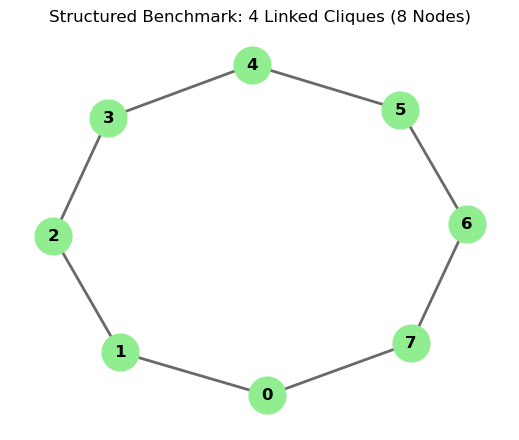

Calculating exact classical baseline...
True Maximum Modularity (C_bkv): 0.281250
Total Qubits Required: 16


In [43]:
print("=== 1. GRAPH SETUP & BASELINE (Ring of Cliques) ===")

# Generate a highly structured graph: 4 distinct cliques, connected in a ring.
# 4 cliques * 2 nodes each = 8 nodes total. 
# This guarantees a perfect, high-fidelity 4-community landscape.
G_simple = nx.ring_of_cliques(num_cliques=4, clique_size=2)
k_target = 4
n_nodes = G_simple.number_of_nodes()
n_qubits = total_qubits(n_nodes, k_target)

# VISUALIZATION
plt.figure(figsize=(5, 4))
pos = nx.spring_layout(G_simple, seed=42) 
nx.draw(
    G_simple, 
    pos, 
    with_labels=True, 
    node_color='lightgreen', 
    edge_color='dimgray',
    width=2.0,
    font_weight='bold',
    node_size=700
)
plt.title(f"Structured Benchmark: 4 Linked Cliques ({n_nodes} Nodes)")
plt.show()

# Calculate absolute true baseline
print("Calculating exact classical baseline...")
true_baseline = best_known_community_cost(G_simple, k=k_target)
print(f"True Maximum Modularity (C_bkv): {true_baseline_simple:.6f}")
print(f"Total Qubits Required: {n_qubits}")

In [44]:
print("\n=== 2. L-VQE (COBYLA) EXECUTION ===")

# Build the exact qubit-frugal Hamiltonian
H_comm = build_k_community_hamiltonian(G_simple, k_target)

# Run L-VQE with COBYLA
rng_cobyla = np.random.default_rng(42)
cobyla_results = simulate_one_lvqe(
    n_q=n_qubits,
    H=H_comm,
    max_layers=2,
    shots=None,               # Statevector simulation
    max_iter_per_layer=600,   # Gives the 3,000 total budget
    rng=rng_cobyla,
    optimizer="COBYLA",
    device_name="lightning.qubit"
)

# Remember: VQE minimizes cost (negative modularity), so we flip the sign
cobyla_modularity = -cobyla_results['final_cost']
cobyla_rho = cobyla_modularity / true_baseline

print(f"\nCOBYLA Final Modularity: {cobyla_modularity:.6f}")
print(f"COBYLA Approximation Ratio (ρ): {cobyla_rho:.4f}")


=== 2. L-VQE (COBYLA) EXECUTION ===
  Layer 0  (16 params) ... cost = -0.281246
  Layer 1  (76 params) ... cost = -0.281249
  Layer 2  (136 params) ... cost = -0.281250

COBYLA Final Modularity: 0.281250
COBYLA Approximation Ratio (ρ): 1.0000


In [45]:
print("\n=== 3. L-VQE (SMO) EXECUTION ===")

# We use the exact same random seed so both optimizers start on the exact same point on the mountain
rng_smo = np.random.default_rng(42) 

smo_results = simulate_one_lvqe(
    n_q=n_qubits,
    H=H_comm,
    max_layers=2,
    shots=None,
    max_iter_per_layer=600,
    rng=rng_smo,
    optimizer="SMO",
    device_name="lightning.qubit"
)

smo_modularity = -smo_results['final_cost']
smo_rho = smo_modularity / true_baseline

print(f"\nSMO Final Modularity: {smo_modularity:.6f}")
print(f"SMO Approximation Ratio (ρ): {smo_rho:.4f}")


=== 3. L-VQE (SMO) EXECUTION ===
  Layer 0  (16 params) ... cost = -0.250000
  Layer 1  (76 params) ... cost = -0.281250
  Layer 2  (136 params) ... cost = -0.281250

SMO Final Modularity: 0.281250
SMO Approximation Ratio (ρ): 1.0000



=== 4. OPTIMIZER TRAJECTORY COMPARISON ===


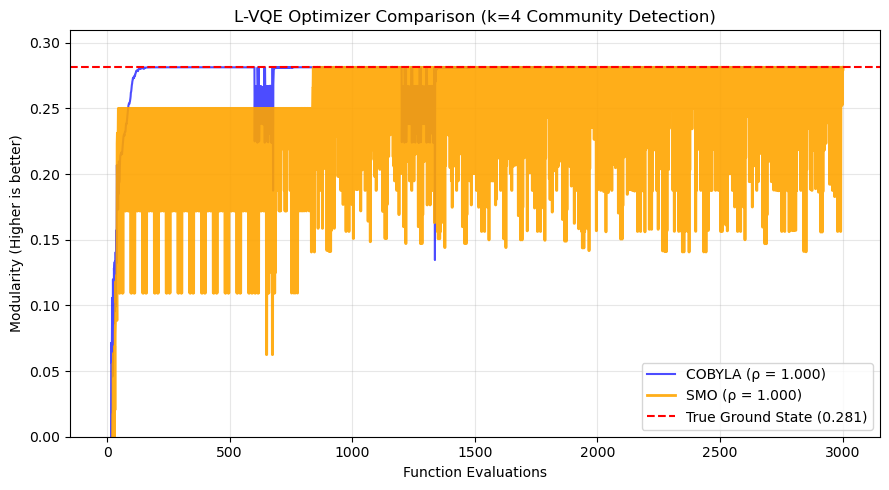

In [46]:
print("\n=== 4. OPTIMIZER TRAJECTORY COMPARISON ===")
plt.figure(figsize=(9, 5))

# Convert VQE costs back to positive modularity for the plot
plt.plot([-c for c in cobyla_results["cost_history"]], label=f"COBYLA (ρ = {cobyla_rho:.3f})", color='blue', alpha=0.7)
plt.plot([-c for c in smo_results["cost_history"]], label=f"SMO (ρ = {smo_rho:.3f})", color='orange', alpha=0.9, linewidth=2)

# Plot the absolute classical ceiling
plt.axhline(true_baseline, color="red", linestyle="--", linewidth=1.5, label=f"True Ground State ({true_baseline:.3f})")

plt.title("L-VQE Optimizer Comparison (k=4 Community Detection)")
plt.xlabel("Function Evaluations")
plt.ylabel("Modularity (Higher is better)")
plt.ylim(0, true_baseline * 1.1)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import time
import pandas as pd
import numpy as np
import networkx as nx
import pennylane as qml
from pennylane import numpy as pnp # Precautionary as requested

# Import from your engine
from l_vqe_engine import (
    build_k_community_hamiltonian,
    best_known_community_cost,
    simulate_one_lvqe,
    simulate_one_qaoa,
    total_qubits
)

print("=== STARTING MASSIVE BATCH ANALYSIS ===")

# --- Configuration ---
graph_sizes = [7, 8, 9, 10]
n_seeds = 10
k_target = 4
device = "lightning.qubit"  # Fast statevector backend

# Budgets
lvqe_evals_per_layer = 600  # Yields 3,000 total (600 + 600 + 1800)
qaoa_evals = 3000           # Gives QAOA the exact same 3,000 budget per run
qaoa_p_values = list(range(1, 11)) # p = 1 to 10

# Master data collection list
results_data = []

for n_nodes in graph_sizes:
    print(f"\n--- Processing Graph: {n_nodes} Nodes ---")
    
    # 1. Generate the exact topology used in the paper
    G = nx.erdos_renyi_graph(n_nodes, p=0.5, seed=42)
    n_q = total_qubits(n_nodes, k_target)
    
    print(f"Calculating true baseline for {n_nodes} nodes...")
    true_baseline = best_known_community_cost(G, k=k_target)
    print('True Baseline:',true_baseline)
    H_comm = build_k_community_hamiltonian(G, k_target)
    
    for seed in range(n_seeds):
        print(f"  Running Seed {seed+1}/{n_seeds}...")
        rng = np.random.default_rng(seed)
        
        # --- A. L-VQE (SMO) ---
        print('L-VQE(SMO):')
        t0 = time.time()
        res_smo = simulate_one_lvqe(
            n_q, H_comm, max_layers=2, shots=None, 
            max_iter_per_layer=lvqe_evals_per_layer, 
            rng=rng, device_name=device, optimizer="SMO"
        )
        rho_smo = -res_smo['final_cost'] / true_baseline
        entry = {"Algorithm": "L-VQE (SMO)", "Nodes": n_nodes, "Seed": seed, "p_or_L": 2, "Rho": rho_smo, "Time_s": time.time()-t0}
        results_data.append(entry)
        #print(entry)

        # --- B. L-VQE (COBYLA) ---
        print('L-VQE(COBYLA):')
        t0 = time.time()
        res_cobyla = simulate_one_lvqe(
            n_q, H_comm, max_layers=2, shots=None, 
            max_iter_per_layer=lvqe_evals_per_layer, 
            rng=rng, device_name=device, optimizer="COBYLA"
        )
        rho_cobyla = -res_cobyla['final_cost'] / true_baseline
        entry = {"Algorithm": "L-VQE (COBYLA)", "Nodes": n_nodes, "Seed": seed, "p_or_L": 2, "Rho": rho_cobyla, "Time_s": time.time()-t0}
        results_data.append(entry)
        #print(entry)

        #--- C. QAOA (p = 1 to 10) ---
        print('QAOA:')
        for p in qaoa_p_values:
            print("p =",p)
            t0 = time.time()
            res_qaoa = simulate_one_qaoa(
                n_q, H_comm, p_steps=p, shots=None, 
                max_evals=qaoa_evals, rng=rng, device_name=device
            )
            rho_qaoa = -res_qaoa['final_cost'] / true_baseline
            results_data.append({"Algorithm": "QAOA", "Nodes": n_nodes, "Seed": seed, "p_or_L": p, "Rho": rho_qaoa, "Time_s": time.time()-t0})

# --- Compile and Export ---
print("\n=== ANALYSIS COMPLETE. COMPILING DATA ===")
df_results = pd.DataFrame(results_data)
csv_filename = "data_community_benchmark.csv"
df_results.to_csv(csv_filename, index=False)
print(f"Data successfully exported to '{csv_filename}'.")

# Display a quick preview of the average performance
display(df_results.groupby(['Algorithm', 'Nodes', 'p_or_L'])['Rho'].mean().unstack(level=0))

=== STARTING MASSIVE BATCH ANALYSIS ===

--- Processing Graph: 7 Nodes ---
Calculating true baseline for 7 nodes...
True Baseline: 0.13223140495867766
  Running Seed 1/10...
L-VQE(SMO):
  Layer 0  (14 params) ... cost = -0.132231
  Layer 1  (66 params) ... cost = -0.132231
  Layer 2  (118 params) ... cost = -0.132231
L-VQE(COBYLA):
  Layer 0  (14 params) ... cost = -0.132231
  Layer 1  (66 params) ... cost = -0.132231
  Layer 2  (118 params) ... cost = -0.132231
QAOA:
p = 1
p = 2
p = 3
p = 4
p = 5
p = 6
p = 7
p = 8
p = 9
p = 10
  Running Seed 2/10...
L-VQE(SMO):
  Layer 0  (14 params) ... cost = -0.099174
  Layer 1  (66 params) ... cost = -0.099174
  Layer 2  (118 params) ... cost = -0.099174
L-VQE(COBYLA):
  Layer 0  (14 params) ... cost = -0.132231
  Layer 1  (66 params) ... cost = -0.132231
  Layer 2  (118 params) ... cost = -0.132231
QAOA:
p = 1
p = 2
p = 3
p = 4
p = 5
p = 6
p = 7
p = 8
p = 9
p = 10
  Running Seed 3/10...
L-VQE(SMO):
  Layer 0  (14 params) ... cost = -0.132231
  La

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

print("=== 5. GENERATING FIGURE 3 REPLICATION ===")

# 1. Load the exported batch data
csv_filename = "data_community_benchmark.csv"
df = pd.read_csv(csv_filename)

# 2. The paper plots the BEST approximation ratio found across the 10 seeds
df_best = df.groupby(['Algorithm', 'Nodes', 'p_or_L'])['Rho'].max().reset_index()

plt.figure(figsize=(8, 5))

# 3. Plot QAOA (Gradient mapping for p=1 to p=10)
qaoa_data = df_best[df_best['Algorithm'] == 'QAOA']
p_values = sorted(qaoa_data['p_or_L'].unique())

# Using viridis to mimic the paper's dark-purple to light-green gradient
colors = cm.viridis(np.linspace(0, 0.85, len(p_values)))

for p, color in zip(p_values, colors):
    subset = qaoa_data[qaoa_data['p_or_L'] == p]
    plt.plot(
        subset['Nodes'], subset['Rho'], 
        marker='o', markersize=5, 
        color=color, alpha=0.8, 
        label=f'p = {p}'
    )

# 4. Plot L-VQE (Bold, distinct lines to stand out against QAOA)
lvqe_smo = df_best[df_best['Algorithm'] == 'L-VQE (SMO)']
plt.plot(
    lvqe_smo['Nodes'], lvqe_smo['Rho'], 
    marker='*', markersize=9, 
    color='gold', linewidth=2.5, 
    label='L-VQE (SMO)'
)

lvqe_cobyla = df_best[df_best['Algorithm'] == 'L-VQE (COBYLA)']
plt.plot(
    lvqe_cobyla['Nodes'], lvqe_cobyla['Rho'], 
    marker='s', markersize=6, 
    color='khaki', linewidth=2.5, linestyle='--', 
    label='L-VQE (COBYLA)'
)

# 5. Formatting to strictly match the paper's style
plt.title("Approximation Ratio vs. Number of Nodes (k=4 Communities)")
plt.xlabel("Number of nodes")
plt.ylabel("Approximation Ratio")

# Lock the ticks and limits to match the manuscript's bounds
plt.xticks([7, 8, 9, 10])
plt.ylim(0.1, 1.05) 

# Force the legend outside the plot area on the right side
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, framealpha=1.0)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# =============================================================
# SECTION: ENTANGLEMENT VS NO ENTANGLEMENT
# Replicates Section VI-D and Table 10 from the paper
# =============================================================

import pandas as pd
import time

print("=== ENTANGLEMENT VS NO ENTANGLEMENT (k=4 Community Detection) ===")

n_seeds = 10
ent_results = {"entanglement": [], "no_entanglement": []}
rows = []

for seed in range(n_seeds):
    print(f"\nSeed {seed+1}/{n_seeds}")

    rng = np.random.default_rng(seed)
    t0 = time.time()
    res_ent = simulate_one_lvqe(
        n_q=n_qubits,
        H=H_comm,
        max_layers=1,
        shots=None,
        max_iter_per_layer=600,
        rng=rng,
        optimizer="SMO",
        device_name="lightning.qubit",
        no_entanglement=False
    )
    t_ent = time.time() - t0
    rho_ent = -res_ent['final_cost'] / true_baseline
    ent_results["entanglement"].append(rho_ent)
    print(f"  With entanglement    → ρ = {rho_ent:.4f}  ({t_ent:.1f}s)")

    rows.append({
        "Algorithm": "L-VQE Entanglement",
        "Nodes":     n_nodes,
        "Seed":      seed,
        "p_or_L":    1,
        "Rho":       rho_ent,
        "Time_s":    t_ent,
    })

    rng = np.random.default_rng(seed)
    t0 = time.time()
    res_no = simulate_one_lvqe(
        n_q=n_qubits,
        H=H_comm,
        max_layers=1,
        shots=None,
        max_iter_per_layer=600,
        rng=rng,
        optimizer="SMO",
        device_name="lightning.qubit",
        no_entanglement=True
    )
    t_no = time.time() - t0
    rho_no = -res_no['final_cost'] / true_baseline
    ent_results["no_entanglement"].append(rho_no)
    print(f"  Without entanglement → ρ = {rho_no:.4f}  ({t_no:.1f}s)")

    rows.append({
        "Algorithm": "L-VQE No Entanglement",
        "Nodes":     n_nodes,
        "Seed":      seed,
        "p_or_L":    1,
        "Rho":       rho_no,
        "Time_s":    t_no,
    })

df_ent_community = pd.DataFrame(rows)
df_ent_community.to_csv("data_entanglement_community.csv", index=False)
print(f"\nSaved to data_entanglement_community.csv")
print(df_ent_community.to_string(index=False))

print("\n" + "="*55)
print("SUMMARY")
print("="*55)
for label, rhos in ent_results.items():
    rhos_arr = np.array(rhos)
    print(f"\n{label}:")
    print(f"  best  = {rhos_arr.max():.4f}")
    print(f"  mean  = {rhos_arr.mean():.4f} ± {rhos_arr.std():.4f}")
    print(f"  >0.99 = {(rhos_arr > 0.99).mean()*100:.1f}%")
    print(f"  >0.95 = {(rhos_arr > 0.95).mean()*100:.1f}%")
    print(f"  >0.90 = {(rhos_arr > 0.90).mean()*100:.1f}%")

=== ENTANGLEMENT VS NO ENTANGLEMENT (k=4 Community Detection) ===

Seed 1/10
  Layer 0  (16 params) ... cost = -0.625000
  Layer 1  (76 params) ... cost = -0.750000
  With entanglement    → ρ = 1.0000  (38.8s)
  Layer 0  (16 params) ... cost = -0.625000
  Layer 1  (76 params) ... cost = -0.625000
  Without entanglement → ρ = 0.8333  (40.4s)

Seed 2/10
  Layer 0  (16 params) ... cost = -0.625000
  Layer 1  (76 params) ... cost = -0.750000
  With entanglement    → ρ = 1.0000  (37.7s)
  Layer 0  (16 params) ... cost = -0.625000
  Layer 1  (76 params) ... cost = -0.625000
  Without entanglement → ρ = 0.8333  (41.7s)

Seed 3/10
  Layer 0  (16 params) ... cost = -0.375000
  Layer 1  (76 params) ... cost = -0.750000
  With entanglement    → ρ = 1.0000  (37.8s)
  Layer 0  (16 params) ... cost = -0.375000
  Layer 1  (76 params) ... cost = -0.375000
  Without entanglement → ρ = 0.5000  (40.5s)

Seed 4/10
  Layer 0  (16 params) ... cost = -0.625000
  Layer 1  (76 params) ... cost = -0.625000
  Wi

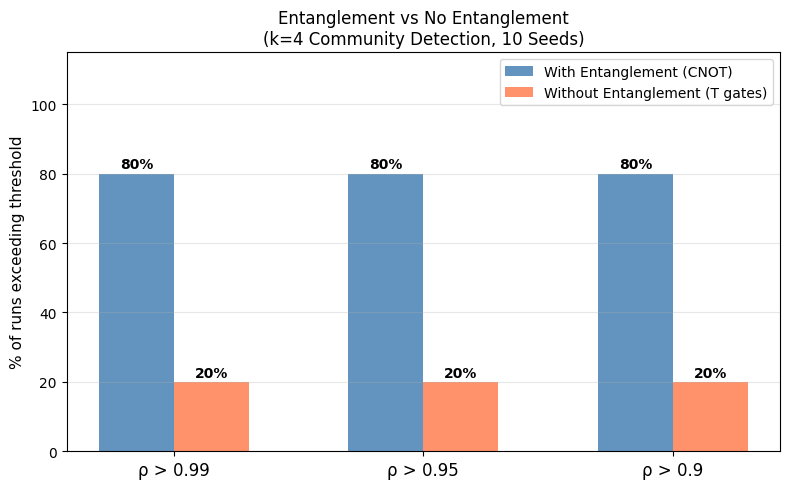

In [14]:
# =============================================================
# PLOT 1: Success rate by threshold - mirrors Table 10 from paper
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_ent_community = pd.read_csv("data_entanglement_community.csv")
ent_arr = df_ent_community[df_ent_community["Algorithm"] == "L-VQE Entanglement"]["Rho"].values
no_arr  = df_ent_community[df_ent_community["Algorithm"] == "L-VQE No Entanglement"]["Rho"].values

thresholds = [0.99, 0.95, 0.90]
x = np.arange(len(thresholds))
width = 0.3

ent_pct = [(ent_arr > t).mean() * 100 for t in thresholds]
no_pct  = [(no_arr  > t).mean() * 100 for t in thresholds]

plt.figure(figsize=(8, 5))
bars_ent = plt.bar(x - width/2, ent_pct, width,
                   label="With Entanglement (CNOT)",
                   color="steelblue", alpha=0.85)
bars_no  = plt.bar(x + width/2, no_pct, width,
                   label="Without Entanglement (T gates)",
                   color="coral", alpha=0.85)

for bar in bars_ent:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f"{bar.get_height():.0f}%",
             ha='center', fontsize=10, fontweight='bold')
for bar in bars_no:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f"{bar.get_height():.0f}%",
             ha='center', fontsize=10, fontweight='bold')

plt.xticks(x, [f"ρ > {t}" for t in thresholds], fontsize=12)
plt.ylabel("% of runs exceeding threshold", fontsize=11)
plt.title("Entanglement vs No Entanglement\n(k=4 Community Detection, 10 Seeds)",
          fontsize=12)
plt.ylim(0, 115)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

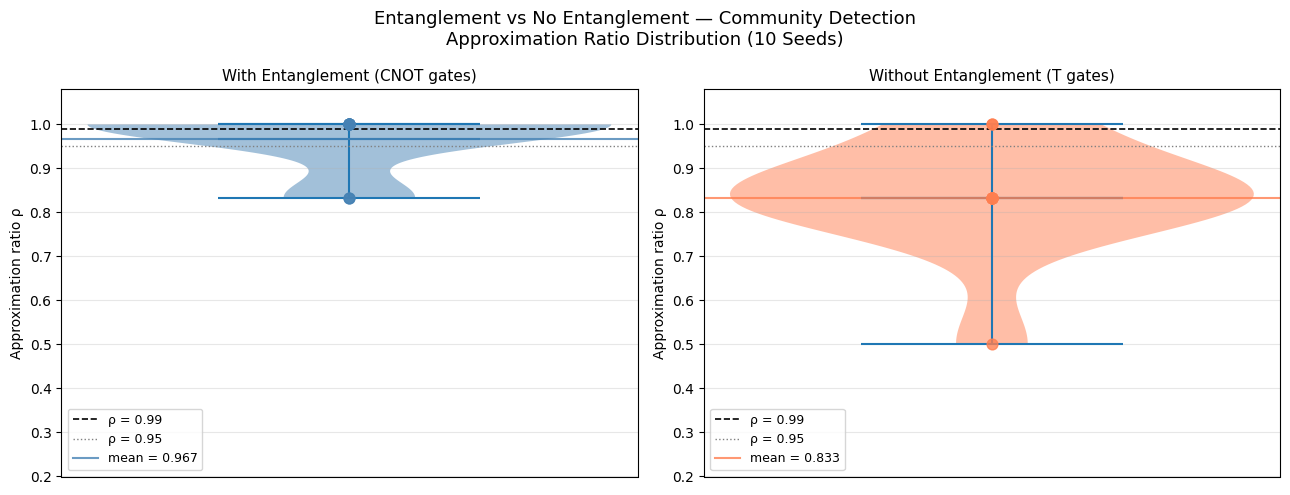

In [15]:
# =============================================================
# PLOT 2: Distribution violin plot
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_ent_community = pd.read_csv("data_entanglement_community.csv")
ent_arr = df_ent_community[df_ent_community["Algorithm"] == "L-VQE Entanglement"]["Rho"].values
no_arr  = df_ent_community[df_ent_community["Algorithm"] == "L-VQE No Entanglement"]["Rho"].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Entanglement vs No Entanglement — Community Detection\n"
             "Approximation Ratio Distribution (10 Seeds)", fontsize=13)

for ax, rhos, color, title in zip(
    axes,
    [ent_arr, no_arr],
    ["steelblue", "coral"],
    ["With Entanglement (CNOT gates)",
     "Without Entanglement (T gates)"]
):
    vp = ax.violinplot([rhos], positions=[1],
                       showmeans=True, showmedians=True)
    for body in vp['bodies']:
        body.set_facecolor(color)
        body.set_alpha(0.5)

    ax.scatter([1]*len(rhos), rhos,
               color=color, alpha=0.8, s=60, zorder=3)

    ax.axhline(0.99, color="black", linestyle="--",
               linewidth=1.2, label="ρ = 0.99")
    ax.axhline(0.95, color="gray", linestyle=":",
               linewidth=1.0, label="ρ = 0.95")
    ax.axhline(rhos.mean(), color=color, linestyle="-",
               linewidth=1.5, alpha=0.8,
               label=f"mean = {rhos.mean():.3f}")

    ax.set_title(title, fontsize=11)
    ax.set_xticks([])
    ax.set_ylabel("Approximation ratio ρ", fontsize=10)
    ax.set_ylim(0.2, 1.08)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()